 📊 SmartHire : Resume Intelligence & Hiring Analytics

This project focuses on analyzing candidate resume data to identify the key factors that influence resume quality and hiring potential. Through exploratory data analysis (EDA), statistical insights, and visualization techniques, the project uncovers patterns in experience, technical skills, soft skills, and other candidate attributes.

In addition to analysis, a machine learning regression model is developed to predict Resume Score (0–100) based on candidate features. The objective is to demonstrate how data analytics and predictive modeling can assist HR teams in making faster, data-driven, and more objective recruitment decisions.

🧠 STEP 1: Setup Environment

In [241]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


📌 STEP 2: Load Dataset

In [204]:
import numpy as np
import pandas as pd

In [205]:
df = pd.read_csv("resume.csv")

In [242]:
df.head()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,Resume Score(0-100),Name_Abigail Watts,Name_Adam Hopkins,Name_Adam Tapia,Name_Adrian Marshall,Name_Adriana Johnson,...,Education_MBA,Education_PhD,Certifications_Deep Learning Specialization,Certifications_Google ML,Certifications_Unknown,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,Recruiter Decision_Reject,Experience_Group
0,1,10,104895,8,100,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,6-10 yrs
1,2,10,113002,1,100,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,6-10 yrs
2,3,1,71766,7,70,False,False,False,False,False,...,True,False,True,False,False,True,False,False,False,0-2 yrs
3,4,7,46848,0,95,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,6-10 yrs
4,5,4,87441,9,100,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,3-5 yrs


In [207]:
df.shape

(1000, 11)

In [208]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'Resume Score(0-100)'],
      dtype='object')

📊 STEP 3: Basic Data Understanding

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  Resume Score(0-100)     1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [210]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,Resume Score(0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [211]:
df.isnull().sum()

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
Resume Score(0-100)         0
dtype: int64

🧹 STEP 4: Data Cleaning

In [212]:
df.fillna("Unknown", inplace=True)

In [213]:
df.drop_duplicates(inplace=True)

In [214]:
df['Experience (Years)'] = df['Experience (Years)'].astype(int)

📈 STEP 5: Exploratory Data Analysis (EDA)

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

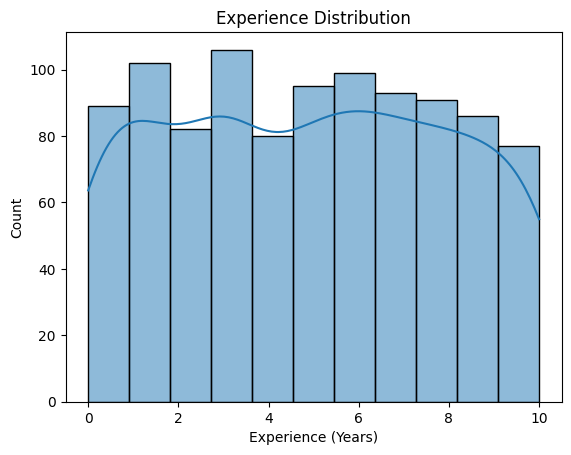

In [216]:
plt.figure()
sns.histplot(df['Experience (Years)'], kde=True)
plt.title("Experience Distribution")
plt.show()

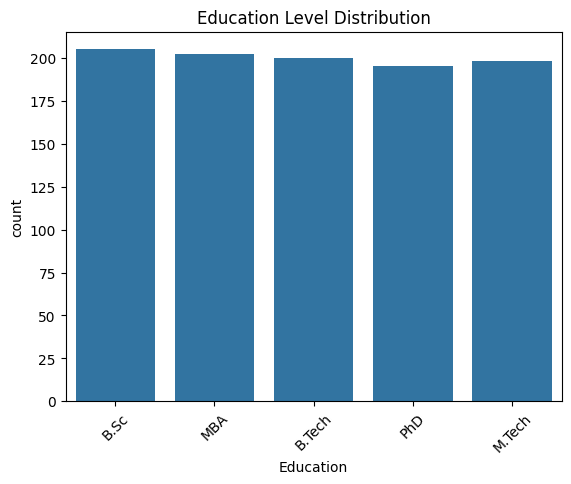

In [217]:
plt.figure()
sns.countplot(x='Education', data=df)
plt.xticks(rotation=45)
plt.title("Education Level Distribution")
plt.show()

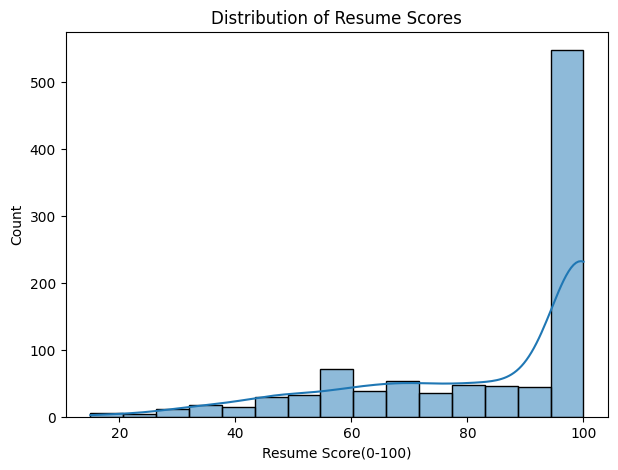

In [218]:
plt.figure(figsize=(7,5))
sns.histplot(df["Resume Score(0-100)"], kde=True)
plt.title("Distribution of Resume Scores")
plt.show()

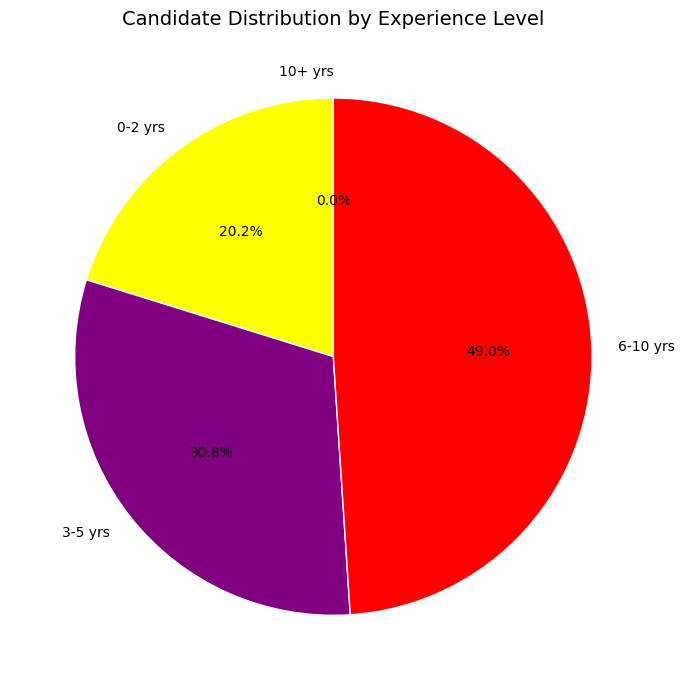

In [239]:
df['Experience_Group'] = pd.cut(df['Experience (Years)'],bins=[0, 2, 5, 10, 20],labels=["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"])

exp_counts = df['Experience_Group'].value_counts().sort_index()

plt.figure(figsize=(7,7))

colors = ["yellow","purple","red"]

plt.pie(exp_counts,labels=exp_counts.index,autopct='%1.1f%%',startangle=90,colors=colors,wedgeprops={'edgecolor': 'white'})

plt.title("Candidate Distribution by Experience Level", fontsize=14)
plt.tight_layout()
plt.show()

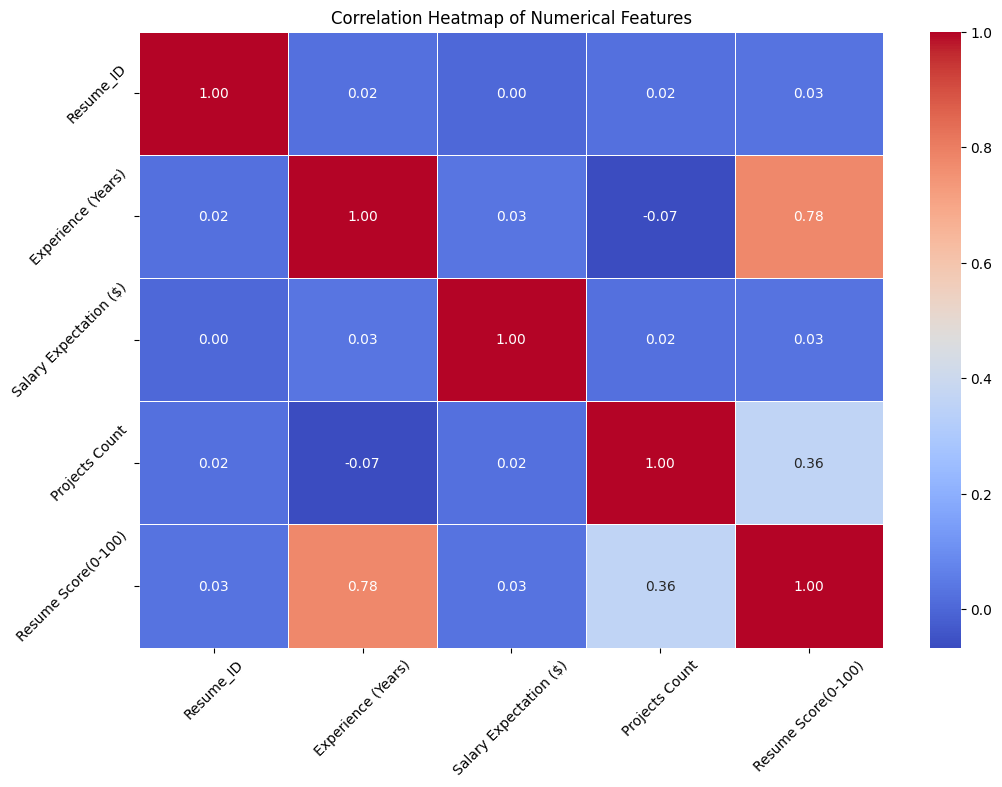

In [240]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()





🤖 STEP 6: Feature Engineering

In [222]:
df = pd.get_dummies(df, drop_first=True)

🧠 STEP 7: Build Prediction Model

In [223]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error

In [225]:
X = df.drop("Resume Score(0-100)", axis=1)
y = df["Resume Score(0-100)"]

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
#R² Score measures how well the model explains the variation in Resume Score (closer to 1 means better performance). 

print("MAE:", mean_absolute_error(y_test, predictions))
#Mean Absolute Error shows the average difference between actual and predicted scores.low MAE indicate a strong and accurate prediction model.  


R2 Score: 0.9695449135188074
MAE: 2.4942499999999996
